In [40]:
#Install textblob
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

In [3]:
# Load dataset
columns = ['sentiment','id','date','query','user','text']
df = pd.read_csv(
    r"C:\Coding_Samurai_Internship\training.1600000.processed.noemoticon.csv\training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    names=columns,
)
# Display first 5 rows
print(df.head())

   sentiment          id                          date     query  \
0          0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1          0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2          0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3          0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4          0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  


In [5]:
# Select random sample for faster processing
df = df.sample(10000, random_state=42)

In [42]:
# Keep only sentiment label and tweet text
df = df[['sentiment', 'text']]

In [27]:
# Convert positive label from 4 to 1
df['sentiment'] = df['sentiment'].replace(4, 1)
print(df['sentiment'].value_counts())

sentiment
0    5004
1    4996
Name: count, dtype: int64


In [43]:
# Function to determine tweet sentiment using TextBlob
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [44]:
# Apply sentiment analysis to all tweets
df["Prediction"] = df["text"].apply(get_sentiment)

In [45]:
# Display sample predictions
print(df[["text", "Prediction"]].head())

                                                     text Prediction
541200             @chrishasboobs AHHH I HOPE YOUR OK!!!    Positive
750     @misstoriblack cool , i have no tweet apps  fo...   Positive
766711  @TiannaChaos i know  just family drama. its la...   Negative
285055  School email won't open  and I have geography ...   Negative
705995                             upper airways problem     Neutral


In [31]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
# Count number of positive, negative and neutral tweets
print(df["Prediction"].value_counts())

Prediction
Positive    4358
Neutral     3568
Negative    2074
Name: count, dtype: int64


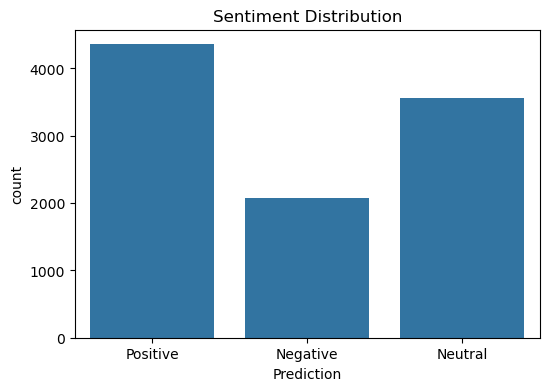

In [47]:
plt.figure(figsize=(6,4))
# Visualize sentiment distribution
sns.countplot(
    x="Prediction",
    data=df
)
plt.title("Sentiment Distribution")
plt.show()

In [48]:
# Convert sentiment categories into numeric labels
df["Predicted_Label"] = df["Prediction"].map({
    "Negative":0,
    "Neutral":0,
    "Positive":1
})

In [49]:
# Compare TextBlob predictions with original dataset labels
accuracy = (
    df["Predicted_Label"] == df["sentiment"]
).mean()
print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Accuracy: 62.4 %


In [50]:
# Display final prediction examples
print(
    df[
        ["text",
         "Prediction"]
    ].head(10)
)

                                                      text Prediction
541200              @chrishasboobs AHHH I HOPE YOUR OK!!!    Positive
750      @misstoriblack cool , i have no tweet apps  fo...   Positive
766711   @TiannaChaos i know  just family drama. its la...   Negative
285055   School email won't open  and I have geography ...   Negative
705995                              upper airways problem     Neutral
379611          Going to miss Pastor's sermon on Faith...    Negative
1189018            on lunch....dj should come eat with me     Neutral
667030    @piginthepoke oh why are you feeling like that?     Neutral
93541      gahh noo!peyton needs to live!this is horrible    Negative
1097326  @mrstessyman thank you glad you like it! There...   Positive
